In [1]:
import pandas as pd

from src.models import MovingAverageModel
from src.evaluate import AllMetrics
from src.visualise import plot_all

ACTUAL_COL = 'points_next_three'
PREDICTED_COL = 'prediction_next_three'

# Load and predict
df = pd.read_csv('data/merged_data.csv')
model = MovingAverageModel(window=3)
df = model.predict(df)

print(f'Rows: {len(df)}, Seasons: {sorted(df["season"].unique())}')
df[['name', 'season', 'GW', ACTUAL_COL, PREDICTED_COL]].head(10)

/var/folders/wx/6l7zgh9x4cd0fjqhbd7hzs_00000gn/T/ipykernel_13275/1198910178.py:11: DtypeWarning: Columns (25,57,58,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/merged_data.csv')


Rows: 192689, Seasons: ['2016-17', '2017-18', '2018-19', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']


,name,season,GW,points_next_three,prediction_next_three
165770,Aaron_Anselmino,2024-25,25,0.0,NaN
165771,Aaron_Anselmino,2024-25,26,0.0,0.0
165772,Aaron_Anselmino,2024-25,27,0.0,0.0
165773,Aaron_Anselmino,2024-25,28,0.0,0.0
165774,Aaron_Anselmino,2024-25,29,0.0,0.0
165775,Aaron_Anselmino,2024-25,30,0.0,0.0
165776,Aaron_Anselmino,2024-25,31,0.0,0.0
165777,Aaron_Anselmino,2024-25,32,0.0,0.0
165778,Aaron_Anselmino,2024-25,33,0.0,0.0
165779,Aaron_Anselmino,2024-25,34,0.0,0.0


Now compute metrics and plot them.

 season  mean_absolute_error  rank_correlation
2016-17                3.154             0.695
2017-18                3.343             0.674
2018-19                3.438             0.665
2020-21                3.123             0.686
2021-22                3.163             0.681
2022-23                2.899             0.713
2023-24                2.647             0.711
2024-25                2.745             0.720


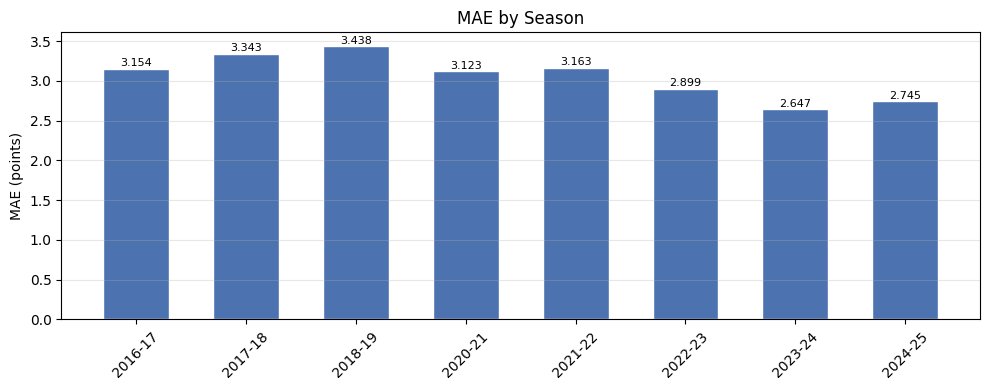

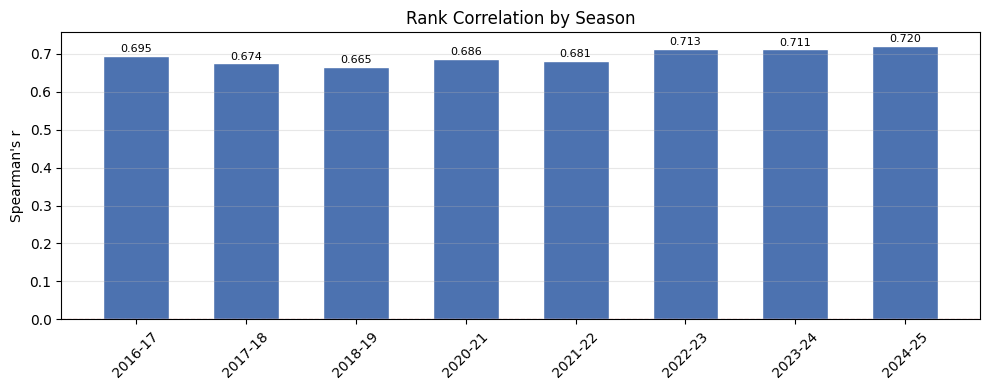

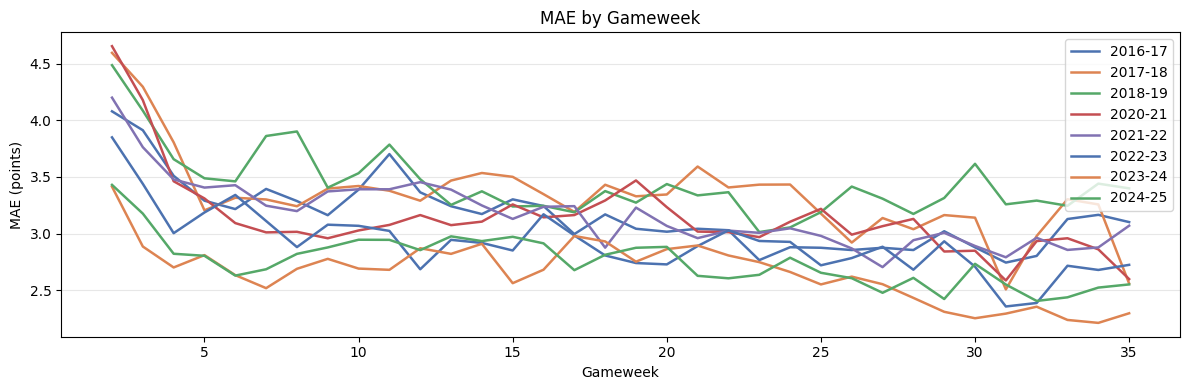

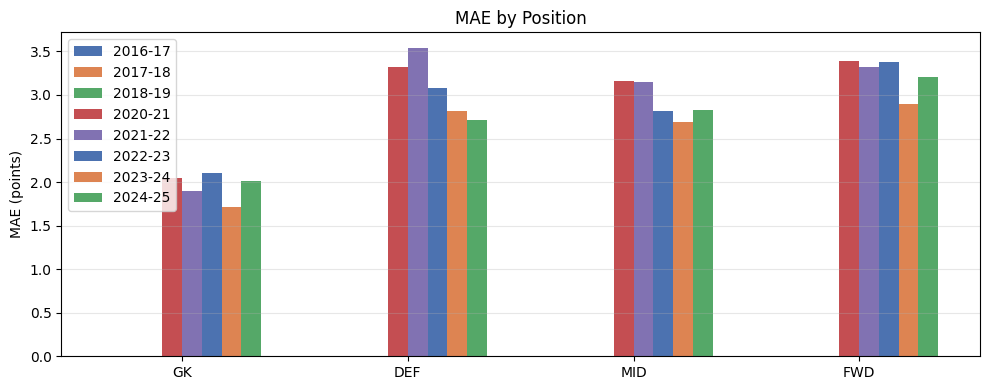

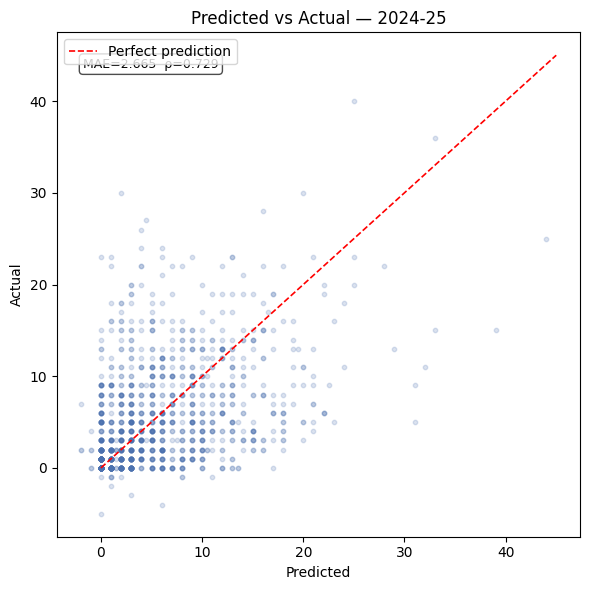

In [2]:
all_metrics = AllMetrics.from_dataframe(df, actual_col=ACTUAL_COL, predicted_col=PREDICTED_COL)

print(all_metrics.summary().to_string(index=False))

plot_all(all_metrics, df, actual_col=ACTUAL_COL, predicted_col=PREDICTED_COL)

In [3]:
df.loc[df.season == "2020-21"]

,name,assists,attempted_passes,big_chances_created,big_chances_missed,bonus,bps,clean_sheets,clearances_blocks_interceptions,completed_passes,...,mng_underdog_draw,mng_underdog_win,mng_win,modified,points_next_three,points_next_five,points_lag1,prediction_next_one,prediction_next_three,prediction_next_five
66037,Aaron_Connolly,0,NaN,NaN,NaN,0,-3,0,NaN,NaN,...,NaN,NaN,NaN,NaN,12.0,16.0,NaN,NaN,NaN,NaN
66038,Aaron_Connolly,0,NaN,NaN,NaN,2,27,1,NaN,NaN,...,NaN,NaN,NaN,NaN,8.0,8.0,1.0,1.000000,3.0,5.000000
66039,Aaron_Connolly,0,NaN,NaN,NaN,0,2,0,NaN,NaN,...,NaN,NaN,NaN,NaN,6.0,7.0,8.0,4.500000,13.5,22.500000
66040,Aaron_Connolly,0,NaN,NaN,NaN,0,7,0,NaN,NaN,...,NaN,NaN,NaN,NaN,4.0,5.0,2.0,3.666667,11.0,18.333333
66041,Aaron_Connolly,1,NaN,NaN,NaN,0,13,0,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,3.0,2.0,4.000000,12.0,20.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88907,Ørjan_Nyland,0,NaN,NaN,NaN,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.000000,0.0,0.000000
88908,Ørjan_Nyland,0,NaN,NaN,NaN,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.000000,0.0,0.000000
88909,Ørjan_Nyland,0,NaN,NaN,NaN,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,0.0,0.000000
88910,Ørjan_Nyland,0,NaN,NaN,NaN,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,0.0,0.000000


In [4]:
pd.DataFrame(all_metrics.seasons["2020-21"].by_gameweek)

,1,2,3,4,5,6,7,8,9,10,...,29,30,31,32,33,34,35,36,37,38
mean_absolute_error,None,4.656,4.179,3.462,3.310,3.092,3.010,3.015,2.958,3.027,...,2.841,2.848,2.585,2.933,2.958,2.860,2.597,None,None,None
rank_correlation,None,0.608,0.603,0.632,0.674,0.707,0.724,0.689,0.700,0.702,...,0.701,0.691,0.726,0.728,0.749,0.712,0.705,None,None,None


In [5]:
df.loc[(df.season == "2020-21") & (df.GW == 36), "name"].value_counts()

name
Aaron_Connolly               1
Matthew_Lowton               1
Matt_Phillips                1
Matt_Ritchie                 1
Matt_Targett                 1
                            ..
Gary_Cahill                  1
Gareth_Bale                  1
Gaetano_Berardi              1
Gabriel_Fernando_de_Jesus    1
Ørjan_Nyland                 1
Name: count, Length: 566, dtype: int64